In this report, I focus on two SQL relational databases---"Salika"and "The Beverage Company". The first database stores data for a video rental company and the second includes data for a soft drink beverage distributor. For each of the two databases, I use value chain theory to define a business objective which can help the company improve performance, followed by proposing 2-3 business questions, conducting queries using SQL in Python (and in MySQL Workbench for the beverage database), and creating visualizations in Python. Finally, through analyzing the business questions, I propose 2-3 recommendations for the company to make decision in order to reach the business objective. The analysis structure for each of the two databases is generally as below:

 1. Introduction of the database
 2. Business objective
 3. Related business questions & analysis
    - 3.1 Business question 1
        - 3.1.1 Description of the question
        - 3.1.2 Query
        - 3.1.3 Visualization
        - 3.1.4 Analysis
    - 3.2 Business question 2 
        - 3.2.1 Description of the question
        - 3.2.2 Query
        - 3.2.3 Visualization
        - 3.2.4 Analysis
    - 3.3 Business question 3
        - 3.3.1 Description of the question
        - 3.3.2 Query
        - 3.3.3 Visualization
        - 3.3.4 Analysis
    - 3.4 Business question 4 (if applicable)
        - 3.4.1 Description of the question
        - 3.4.2 Query
        - 3.4.3 Visualization
        - 3.4.4 Analysis
 4. Conclusion & Recommendations 
      - 4.1 Decision 1
      - 4.2 Decision 2
      - 4.3 Decision 3 (if applicable)
 5. Appendix 1-Codes for overviewing the tables in the database
 6. Appendix 2-Snapshots for queries in MySQL Workbench (for the beverage company database only)


## Scenario 1: Salika

### 1. Introduction of the database

The Salika database is a relational database that stores various data for a video rental store. The database contains 15 valid tables including one table recording each rental transaction's unique id, payment date, who rented this copy from which staff at when and paid how many dollars for this rental. Based on the payment info table, other data related to this transaction can be found by looking for ids for a specific transaction such as rental id, payment id, staff id, customer id, etc. By linking through the ids, users are able to find each copy's film name, film category, language and some other information for a film. The users can also find each transaction's store, staff and customer infomation. 

The codings in appendix overview each table in this database. According to the overview, there are 16,000+ rental transactions in this companies' two stores across 2005 and 2006. All these transactions were to rent 1,000 films in English that belong to 16 different categories. The content below will look at how to reach a specific business objective for this company. 

### 2. Business objective

The objective defined for the video rental company in this project is to increase revenues by adding inventories for Top 5 profitable films for each store. Maximizing revenues while minimizing cost is the core interest for most private sectors as this will increase the profit of a company. Due to the unavailability of cost data such as payroll, real estate rent, marketing, etc, we will use its revenue from renting videos (the "amount" field in payment table) as a proxy. To come up with revenue increase strategies, questions below are analyzed:

### 3. Related business questions & analysis

#### 3.1 Business question 1: What is the current inventories' status by film category? 

In [21]:
#### Corresponding query:
salika_q1 = pd.read_sql("""

SELECT c.name category, count(i.film_id) counts
From inventory as i
LEFT JOIN film_category as f
ON i.film_id = f.film_id
LEFT JOIN category as c
ON f.category_id = c.category_id
GROUP BY category
ORDER BY counts DESC
LIMIT 5

""", conn)
salika_q1

,category,counts
0,Sports,344
1,Animation,335
2,Sci-Fi,312
3,Action,312
4,Family,310


#### 3.2 Business question 2: Currently, what categorys' films generate the highest rental revenues? Are there any gap between most profitable categories and categories with the highest inventories? 

In [22]:
#### Corresponding query:
salika_q2 = pd.read_sql("""

SELECT c.name category,sum(p.amount) total_payment
From payment as p
LEFT JOIN rental as r
ON p.rental_id = r.rental_id
LEFT JOIN inventory as i
ON r.inventory_id = i.inventory_id
LEFT JOIN film_category as f
ON i.film_id = f.film_id
LEFT JOIN category as c
ON f.category_id = c.category_id
WHERE p.rental_id >0
GROUP BY category
ORDER BY total_payment DESC
LIMIT 5

""", conn)
salika_q2

,category,total_payment
0,Sports,5314.21
1,Sci-Fi,4756.98
2,Animation,4656.30
3,Drama,4587.39
4,Comedy,4383.58


Text(0.5, 0, '')

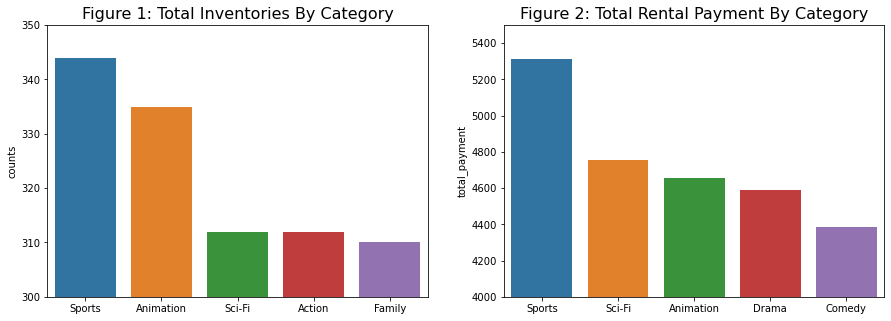

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

####Corresponding visualization for query 1
sns.barplot(ax=axes[0], x=salika_q1.category, y=salika_q1.counts)
axes[0].set_title("Figure 1: Total Inventories By Category", fontsize=16)
axes[0].set_ylim(300,350)
axes[0].set_xlabel("")

####Corresponding visualization for query 2
sns.barplot(ax=axes[1], x=salika_q2.category, y=salika_q2.total_payment)
axes[1].set_title("Figure 2: Total Rental Payment By Category",fontsize=16)
axes[1].set_ylim(4000,5500)
axes[1].set_xlabel("")


#### Analysis for Q1 & Q2
The answers to the two questions above suggest that currently, the stores have a higher inventory for films in sports, animation, sci-fi, action and family. However, when it comes to rental payment, only sports and animations inventories match the revenues they generate. The company has a lower inventories for sci-fi, drama and comedy films. 

#### 3.3 Business question 3: Are there any differences between the two stores? 
Analysis on this question will help the company decide if they need to take different strategies for two stores in order to increase revenues.

In [24]:
#### Corresponding query 3-count of inventories by category and store:

salika_q3 = pd.read_sql("""
SELECT * 
FROM 
(SELECT i.store_id store,c.name category,count(i.film_id) counts,
 row_number() OVER (PARTITION BY i.store_id ORDER BY 
 count(i.film_id) DESC ) as cate_rank
From inventory as i
LEFT JOIN film_category as f
ON i.film_id = f.film_id
LEFT JOIN category as c
ON f.category_id = c.category_id
GROUP BY category, store) ranks 
WHERE cate_rank <=5

""", conn)
salika_q3



,store,category,counts,cate_rank
0,1,Action,169,1
1,1,Sports,163,2
2,1,Drama,162,3
3,1,Animation,161,4
4,1,Family,157,5
5,2,Sports,181,1
6,2,Animation,174,2
7,2,Documentary,164,3
8,2,Sci-Fi,163,4
9,2,Family,153,5


In [25]:
#### Corresponding query 4-rental payments by category and store:

salika_q4 = pd.read_sql("""
SELECT * 
FROM
(SELECT i.store_id store,c.name category, sum(p.amount) total_payment,  
 row_number() OVER (PARTITION BY i.store_id ORDER BY 
 sum(p.amount) DESC ) as cate_rank
From payment as p
LEFT JOIN rental as r
ON p.rental_id = r.rental_id
LEFT JOIN inventory as i
ON r.inventory_id = i.inventory_id
LEFT JOIN film_category as f
ON i.film_id = f.film_id
LEFT JOIN category as c
ON f.category_id = c.category_id
WHERE p.rental_id >0
GROUP BY category, store) ranks
WHERE cate_rank <=5

""", conn)
salika_q4

,store,category,total_payment,cate_rank
0,1,Drama,2573.24,1
1,1,Sports,2488.46,2
2,1,New,2402.98,3
3,1,Comedy,2377.97,4
4,1,Action,2342.04,5
5,2,Sports,2825.75,1
6,2,Sci-Fi,2553.19,2
7,2,Animation,2359.01,3
8,2,Documentary,2348.01,4
9,2,Games,2197.87,5


Text(0.5, 0, '')

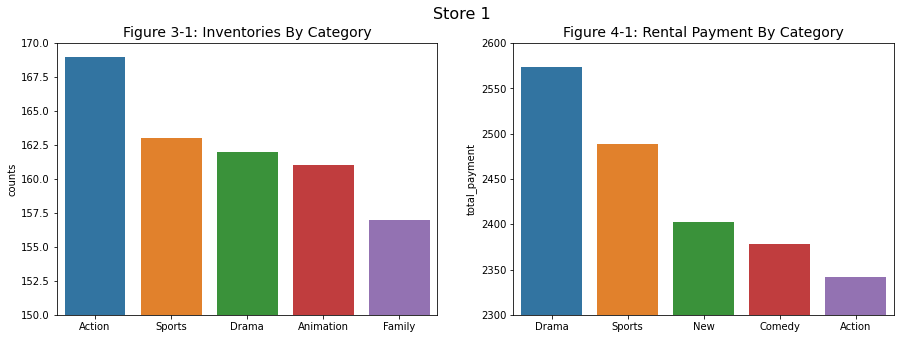

In [26]:
#### Corresponding visualization for Store 1:
salika_q3_s1=salika_q3[salika_q3.store==1]
salika_q4_s1=salika_q4[salika_q4.store==1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Store 1', fontsize=16)

sns.barplot(ax=axes[0], x=salika_q3_s1.category, y=salika_q3_s1.counts)
axes[0].set_title("Figure 3-1: Inventories By Category", fontsize=14)
axes[0].set_ylim(150,170)
axes[0].set_xlabel("")

sns.barplot(ax=axes[1], x=salika_q4_s1.category, y=salika_q4_s1.total_payment)
axes[1].set_title("Figure 4-1: Rental Payment By Category",fontsize=14)
axes[1].set_ylim(2300,2600)
axes[1].set_xlabel("")


#### Analysis for Q3-Store 1
For Store-1, news and comedy films are the Top 5 most profitable movies but with a lower inventories. Drama is very profitable in Store 1 but does not have as many copies as action, a category also made lots of profits in Store 1 but not as strong as other categories mentioned above. 

Text(0.5, 0, '')

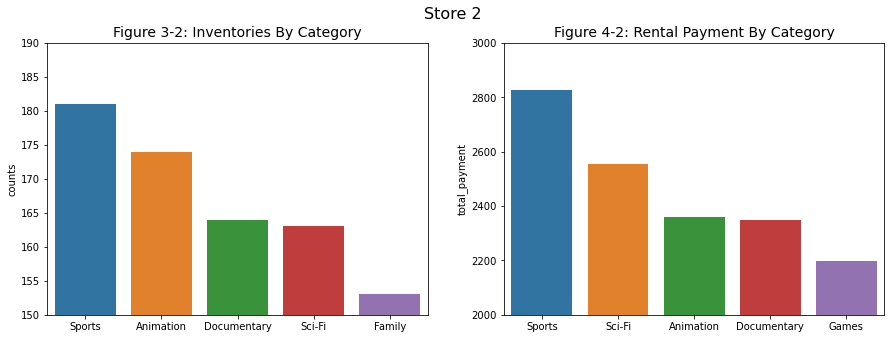

In [27]:
#### Corresponding visualization for Store 2:
salika_q3_s2=salika_q3[salika_q3.store==2]
salika_q4_s2=salika_q4[salika_q4.store==2]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Store 2', fontsize=16)

sns.barplot(ax=axes[0], x=salika_q3_s2.category, y=salika_q3_s2.counts)
axes[0].set_title("Figure 3-2: Inventories By Category", fontsize=14)
axes[0].set_ylim(150,190)
axes[0].set_xlabel("")

sns.barplot(ax=axes[1], x=salika_q4_s2.category, y=salika_q4_s2.total_payment)
axes[1].set_title("Figure 4-2: Rental Payment By Category",fontsize=14)
axes[1].set_ylim(2000,3000)
axes[1].set_xlabel("")


#### Analysis for Q3-Store 2
For Store-2, it's lack of Games, a Top 5 category in terms of revenues in this store. Meanwhile, compared to its revenue-creating ability, sci-fi movies' inventories are also short.

### 4. Conclusion & Recommendations
Based on the study above, we identified a few gaps between categories with higher inventories and categories that generated more revenues for the company as well as for each store. Therefore, following recommendations are made in order to help the company narrow the gap and increase revenues: 

1. Overall, keep maintaining a sufficient inventory for sports as this is a very profit category in both stores. 
2. Try to find more drama, comedy and news movies for Store 1 to replace some action, family and animation movies. 
3. Collect more games and sci-fi movies for Store 2 to replace some family copies.

## Scenario 2: The Beverage Company

### 1. Introduction of the database
The beverage company database stores data for a soft drink distributor. The distributor gets 13 beverage products supplies from 3 suppliers and sells the products to retailers. All the 13 products are categorized into 4 families including cola, root beer, cream soda and fruit soda. The salesfact table records in a specific day in 2000, how many revenues are made from the selling of which product in which state provided by which supplier and what are the corresponding expenses such as cost of goods, marketing expense, payroll and miscellaneous expenses. The salesfact table also keeps track of the opening inventories for a product and its budget. Based on the ids of state, product, supplier, users will be able to know the product's family and whether the market (state) is a major or small market. 

Appendix 1 shows an overview of all 11 tables in this database. Appendix 2 includes snapshots of SQL queries in MySQL Workbench. 

### 2. Business objective
The objective of beverage company is to increase profit by promoting popular family product(s) in both major and small markets and adjust strategies according to profits' seasonalities. In order to find the proper families, both profit and net profit margin will be studied in two sizes' markets. Profit is in dollars unit. Net profit margin is in percent unit and measures how many net dollars are made from 1 dollar's sales. Even if a family does not generate as many profits as others, it may still worth marketing expenses and investment when its net profit margin is high because it means products in this family has higher ability to make profit. 

Below equations show the calculation of the two indicators:

1). Profit = Sales - COGS - Marketing - Payroll -Miscellaneous

2). Net profit margin = Profit / Sales * 100

### 3. Related business questions & analysis

#### 3.1 Business question 1: Which family product generates the most profit in major and small market. 
#### 3.2 Business question 2: Are there any seasonalities for each family product's profitablity in major and small market? 

In [44]:
#### Corresponding query 1-Major market's profit:
tbc_q1 = pd.read_sql("""
SELECT prof_t.FAMILY_ALIAS, month,  sales-cogs-market-payroll-misc as ttl_prof
FROM
(SELECT f.FAMILY_ALIAS , month(s1.TRANSDATE) month, 
 sum(s1.SALES) sales, sum(s1.COGS) cogs, 
 sum(s1.MARKETING) market, sum(s1.PAYROLL) payroll, 
 sum(s1.MISC) misc
From salesfact as s1
LEFT JOIN market as m1
ON s1.STATEID = m1.STATEID
LEFT JOIN product as p
ON s1.PRODUCTID = p.PRODUCTID
LEFT JOIN family as f
ON p.FAMILYID = f.FAMILYID
LEFT JOIN scenario as s2
ON s1.SCENARIOID = s2.SCENARIOID
WHERE s2.SCENARIO = "Actual" 
AND m1.UDAMKTSIZE = "Major Market"
GROUP BY f.FAMILY_ALIAS, month(s1.TRANSDATE)
ORDER BY f.FAMILY_ALIAS, month(s1.TRANSDATE)) AS prof_t

""", cnx)
tbc_q1.head()



/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,FAMILY_ALIAS,month,ttl_prof
0,Colas,1,1671.0
1,Colas,2,1602.0
2,Colas,3,1643.0
3,Colas,4,1715.0
4,Colas,5,1850.0


In [45]:
#### Corresponding query 2-Small market's profit:
tbc_q2 = pd.read_sql("""
SELECT prof_t.FAMILY_ALIAS, month,  sales-cogs-market-payroll-misc as ttl_prof
FROM
(SELECT f.FAMILY_ALIAS , month(s1.TRANSDATE) month, 
 sum(s1.SALES) sales, sum(s1.COGS) cogs, 
 sum(s1.MARKETING) market, sum(s1.PAYROLL) payroll, 
 sum(s1.MISC) misc
From salesfact as s1
LEFT JOIN market as m1
ON s1.STATEID = m1.STATEID
LEFT JOIN product as p
ON s1.PRODUCTID = p.PRODUCTID
LEFT JOIN family as f
ON p.FAMILYID = f.FAMILYID
LEFT JOIN scenario as s2
ON s1.SCENARIOID = s2.SCENARIOID
WHERE s2.SCENARIO = "Actual" 
AND m1.UDAMKTSIZE = "Small Market"
GROUP BY f.FAMILY_ALIAS, month(s1.TRANSDATE)
ORDER BY f.FAMILY_ALIAS, month(s1.TRANSDATE)) AS prof_t

""", cnx)
tbc_q2.head()


/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,FAMILY_ALIAS,month,ttl_prof
0,Colas,1,684.0
1,Colas,2,727.0
2,Colas,3,721.0
3,Colas,4,727.0
4,Colas,5,721.0


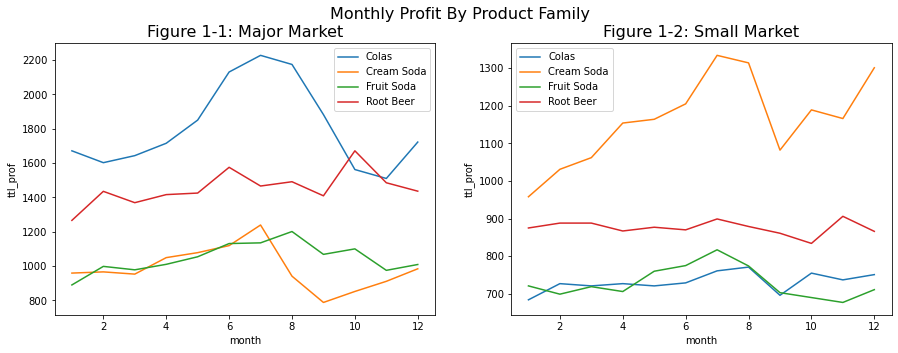

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Monthly Profit By Product Family', fontsize=16)

####Corresponding visualization for query 1
major_market_p=sns.lineplot(ax=axes[0],data=tbc_q1, x="month", 
                            y="ttl_prof", hue="FAMILY_ALIAS")
axes[0].set_title("Figure 1-1: Major Market", fontsize=16)
major_market_p.legend().set_title('')


####Corresponding visualization for query 2
small_market_p=sns.lineplot(ax=axes[1],data=tbc_q2, x="month", 
                            y="ttl_prof", hue="FAMILY_ALIAS")
small_market_p.set_title("Figure 1-2: Small Market", fontsize=16)
small_market_p.legend().set_title('')


#### Analysis for Q1 and Q2:
In major market, colas and root beer were always the leading profitable products throughout the year. In detail, colas consumption was the highest except in fall, when root beer sales became the highest. Colas and root beer dominated profits in major market while sodas had the lowest ability to seek profit. 

Situation in small markets was a bit different: cream soda replaced colas to be the most profitable drink category, particularly in summer when it generated the highest profit throughout the year. Although root beer still had relatively stronger ability to gain profit, colas' status dropped to almost the lowest. But in both markets, fruit soda's profit was low compared to other families.


#### 3.3 Business question 3: Which product family has better net profit margin? Are there any differences between major and small market? 
#### 3.4 Business question 4: Are there any seasonalities for each family product's net profit margin in major and small market? 

In [47]:
#### Corresponding query 3-Major market's profit margin:

tbc_q3 = pd.read_sql("""
SELECT prof_t.FAMILY_ALIAS, month,  
(sales-cogs-market-payroll-misc)/sales*100 as net_profit_margin_pct
FROM
(SELECT f.FAMILY_ALIAS , month(s1.TRANSDATE) month, 
 sum(s1.SALES) sales, sum(s1.COGS) cogs, 
 sum(s1.MARKETING) market, sum(s1.PAYROLL) payroll, 
 sum(s1.MISC) misc
From salesfact as s1
LEFT JOIN market as m1
ON s1.STATEID = m1.STATEID
LEFT JOIN product as p
ON s1.PRODUCTID = p.PRODUCTID
LEFT JOIN family as f
ON p.FAMILYID = f.FAMILYID
LEFT JOIN scenario as s2
ON s1.SCENARIOID = s2.SCENARIOID
WHERE s2.SCENARIO = "Actual" 
AND m1.UDAMKTSIZE = "Major Market"
GROUP BY f.FAMILY_ALIAS, month(s1.TRANSDATE)
ORDER BY f.FAMILY_ALIAS, month(s1.TRANSDATE)) AS prof_t

""", cnx)
tbc_q3.head()


/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,FAMILY_ALIAS,month,net_profit_margin_pct
0,Colas,1,34.689641
1,Colas,2,33.761855
2,Colas,3,34.002483
3,Colas,4,33.634046
4,Colas,5,34.418605


In [48]:
#### Corresponding query 4-Small market's profit margin:

tbc_q4 = pd.read_sql("""
SELECT prof_t.FAMILY_ALIAS, month,  
(sales-cogs-market-payroll-misc)/sales*100 as net_profit_margin_pct
FROM
(SELECT f.FAMILY_ALIAS , month(s1.TRANSDATE) month, 
 sum(s1.SALES) sales, sum(s1.COGS) cogs, 
 sum(s1.MARKETING) market, sum(s1.PAYROLL) payroll, sum(s1.MISC) misc
From salesfact as s1
LEFT JOIN market as m1
ON s1.STATEID = m1.STATEID
LEFT JOIN product as p
ON s1.PRODUCTID = p.PRODUCTID
LEFT JOIN family as f
ON p.FAMILYID = f.FAMILYID
LEFT JOIN scenario as s2
ON s1.SCENARIOID = s2.SCENARIOID
WHERE s2.SCENARIO = "Actual" 
AND m1.UDAMKTSIZE = "Small Market"
GROUP BY f.FAMILY_ALIAS, month(s1.TRANSDATE)
ORDER BY f.FAMILY_ALIAS, month(s1.TRANSDATE)) AS prof_t

""", cnx)
tbc_q4.head()


/opt/anaconda3/lib/python3.9/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,FAMILY_ALIAS,month,net_profit_margin_pct
0,Colas,1,19.559623
1,Colas,2,20.295924
2,Colas,3,20.167832
3,Colas,4,20.273285
4,Colas,5,20.196078


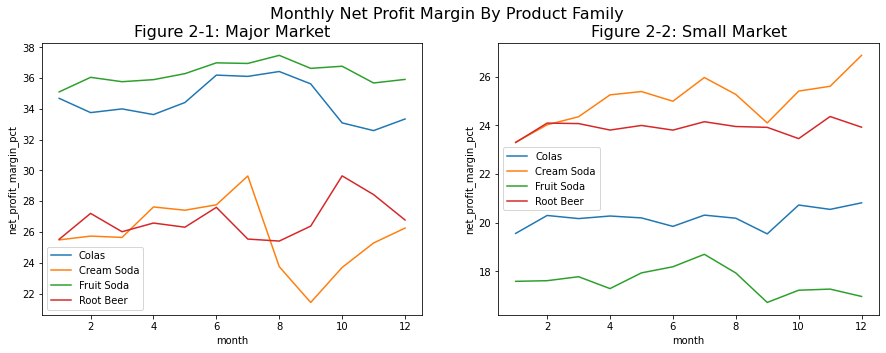

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Monthly Net Profit Margin By Product Family', fontsize=16)

####Corresponding visualization for query 3
major_market_pm=sns.lineplot(ax=axes[0],data=tbc_q3, x="month", 
                             y="net_profit_margin_pct", hue="FAMILY_ALIAS")
axes[0].set_title("Figure 2-1: Major Market", fontsize=16)
major_market_pm.legend().set_title('')


####Corresponding visualization for query 4
small_market_pm=sns.lineplot(ax=axes[1],data=tbc_q4, x="month", 
                             y="net_profit_margin_pct", hue="FAMILY_ALIAS")
axes[1].set_title("Figure 2-2: Small Market", fontsize=16)
small_market_pm.legend().set_title('')


#### Analysis for Q3 and Q4: 
In major market, colas and fruit soda had higher net profit margins, indicating that same revenues from colas and fruit soda can generate more actual profit than from root beer and cream soda. Fruit soda's net profit margin was very stable and had the smallest variation. On the other side, in small market, root beer and cream soda havd higher net profit margins and root beer's ability to make profit was the most stable as its margin's variation was lower. However, fruit soda's margin was the lowest for small market. 

### 4. Conclusion & Recommendations
Based on the analysis above, two recommendations are made for the beverage company:

1. For major markets: The company can implement more promotion activities in summer time for Cola as it was the most profitable product. The company can also invest more in root beer in fall as it was hot profitable season for root beer market. Last but not the least, fruit soda, although had a lower profit in dollars, enjoyed a higher and more stable net profit margin. Therefore, there is big marketing opportunities for fruit soda market. 

2. For small markets: The company can continue investing in cream soda and root beer, particularly cream soda in summer time. However, due to both a low profit and net profit margin, more evaluations should be conducted before deciding whether to invest further in fruit soda. 